In [1]:
import pandas as pd
import numpy as np

In [2]:
movies = pd.read_csv('imdb-top-1000.csv')

In [3]:
movies.head()

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
0,The Shawshank Redemption,1994,142,Drama,9.3,Frank Darabont,Tim Robbins,2343110,28341469.0,80.0
1,The Godfather,1972,175,Crime,9.2,Francis Ford Coppola,Marlon Brando,1620367,134966411.0,100.0
2,The Dark Knight,2008,152,Action,9.0,Christopher Nolan,Christian Bale,2303232,534858444.0,84.0
3,The Godfather: Part II,1974,202,Crime,9.0,Francis Ford Coppola,Al Pacino,1129952,57300000.0,90.0
4,12 Angry Men,1957,96,Crime,9.0,Sidney Lumet,Henry Fonda,689845,4360000.0,96.0


In [114]:
genres = movies.groupby('Genre')
type(genres)

pandas.core.groupby.generic.DataFrameGroupBy

![Screenshot 2026-04-02 024437.png](<attachment:Screenshot 2026-04-02 024437.png>)
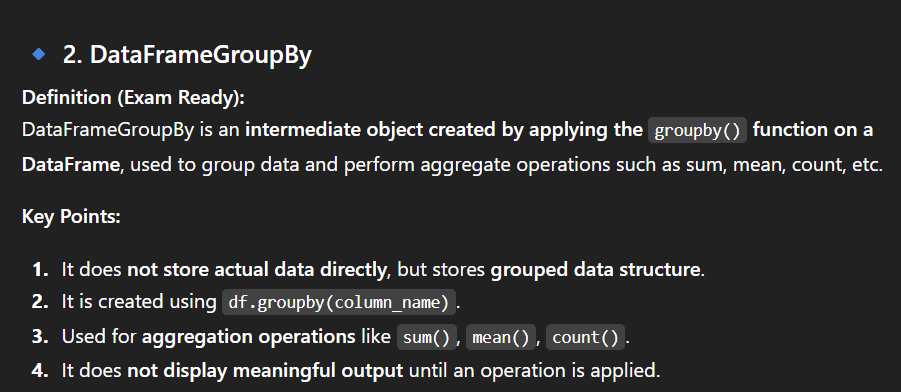

![Screenshot 2026-04-02 023425.png](<attachment:Screenshot 2026-04-02 023425.png>)
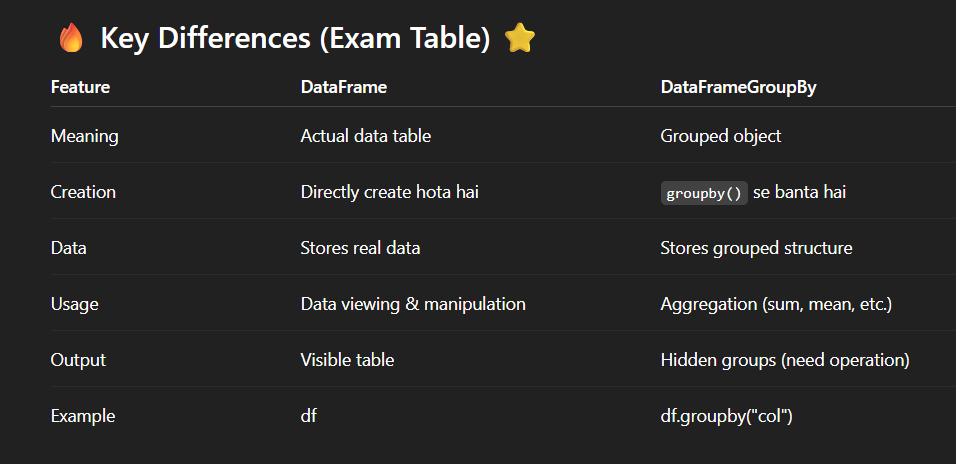

In [14]:
# Applying builtin aggregation fuctions on groupby objects
genres.sum()
genres.max()
genres.min()

,Series_Title,Released_Year,Runtime,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
Genre,,,,,,,,,
Action,300,1924,45,7.6,Abhishek Chaubey,Aamir Khan,25312,3296.0,33.0
Adventure,2001: A Space Odyssey,1925,88,7.6,Akira Kurosawa,Aamir Khan,29999,61001.0,41.0
Animation,Akira,1940,71,7.6,Adam Elliot,Adrian Molina,25229,128985.0,61.0
Biography,12 Years a Slave,1928,93,7.6,Adam McKay,Adrien Brody,27254,21877.0,48.0
Comedy,(500) Days of Summer,1921,68,7.6,Alejandro G. Iñárritu,Aamir Khan,26337,1305.0,45.0
Crime,12 Angry Men,1931,80,7.6,Akira Kurosawa,Ajay Devgn,27712,6013.0,47.0
Drama,1917,1925,64,7.6,Aamir Khan,Abhay Deol,25088,3600.0,28.0
Family,E.T. the Extra-Terrestrial,1971,100,7.8,Mel Stuart,Gene Wilder,178731,4000000.0,67.0
Fantasy,Das Cabinet des Dr. Caligari,1920,76,7.9,F.W. Murnau,Max Schreck,57428,337574718.0,NaN


In [20]:
# find the top 3 genres by total earning
movies.groupby('Genre')['Gross'].sum().sort_values(ascending=False).head(3)

Genre
Drama     3.540997e+10
Action    3.263226e+10
Comedy    1.566387e+10
Name: Gross, dtype: float64

In [21]:
# method 2 this method is slow compare to first bcz isme sare columns phle hi sum ho rahe hai
movies.groupby('Genre').sum()['Gross'].sort_values(ascending=False).head(3)

Genre
Drama     3.540997e+10
Action    3.263226e+10
Comedy    1.566387e+10
Name: Gross, dtype: float64

In [27]:
# find the genre with highest avg IMDB rating
movies.groupby('Genre')['IMDB_Rating'].mean().sort_values(ascending=False).head(1)

Genre
Western    8.35
Name: IMDB_Rating, dtype: float64

In [40]:
# find director with most popularity
movies.groupby('Director')['No_of_Votes'].sum().sort_values(ascending=False).head(1)

Director
Christopher Nolan    11578345
Name: No_of_Votes, dtype: int64

In [ ]:
# find the highest rated movie of each genre

# movies.groupby('Genre')[['Series_Title','IMDB_Rating']]

In [113]:
# find number of movies done by each actor

# movies['Star1'].value_counts()

movies.groupby('Star1')['Series_Title'].count().sort_values(ascending=False)

Star1
Tom Hanks               12
Robert De Niro          11
Al Pacino               10
Clint Eastwood          10
Leonardo DiCaprio        9
                        ..
Zbigniew Zamachowski     1
Zooey Deschanel          1
Çetin Tekindor           1
Éric Toledano            1
Ajay Devgn               1
Name: Series_Title, Length: 660, dtype: int64

In [ ]:
# GroupBy Attributes and Methods
# find total number of groups -> len
# find items in each group -> size
# first()/last() -> nth item
# get_group -> vs filtering
# groups
# describe
# sample
# nunique

    🔹 1. len() → Number of Groups

        Definition:
        len() is used to find the total number of groups formed after applying groupby().

In [116]:
len(movies.groupby('Genre'))

14

In [117]:
movies['Genre'].nunique()

14

    🔹 2. size() → Items in Each Group ⭐

        Definition:
        size() returns the number of rows present in each group.

In [118]:
movies.groupby('Genre').size()

Genre
Action       172
Adventure     72
Animation     82
Biography     88
Comedy       155
Crime        107
Drama        289
Family         2
Fantasy        2
Film-Noir      3
Horror        11
Mystery       12
Thriller       1
Western        4
dtype: int64

    🔹 3. first() / last()

        Definition:
        
        first() → returns the first row of each group
        last() → returns the last row of each group
        nth(index) ->  returns nth row of each group (0-based indexing hota hai)

In [6]:
genres = movies.groupby('Genre')
# genres.first()
# genres.last()
genres.nth(6)

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
16,Star Wars: Episode V - The Empire Strikes Back,1980,124,Action,8.7,Irvin Kershner,Mark Hamill,1159315,290475067.0,82.0
27,Se7en,1995,127,Crime,8.6,David Fincher,Morgan Freeman,1445096,100125643.0,65.0
32,It's a Wonderful Life,1946,130,Drama,8.6,Frank Capra,James Stewart,405801,82385199.0,89.0
66,WALL·E,2008,98,Animation,8.4,Andrew Stanton,Ben Burtt,999790,223808164.0,95.0
83,The Great Dictator,1940,125,Comedy,8.4,Charles Chaplin,Charles Chaplin,203150,288475.0,NaN
102,Braveheart,1995,178,Biography,8.3,Mel Gibson,Mel Gibson,959181,75600000.0,68.0
118,North by Northwest,1959,136,Adventure,8.3,Alfred Hitchcock,Cary Grant,299198,13275000.0,98.0
420,Sleuth,1972,138,Mystery,8.0,Joseph L. Mankiewicz,Laurence Olivier,44748,4081254.0,NaN
724,Get Out,2017,104,Horror,7.7,Jordan Peele,Daniel Kaluuya,492851,176040665.0,85.0


        🔷 value_counts():
                value_counts() is used to count the frequency of unique values within each group.

In [124]:
movies['Genre'].value_counts()
# movies.groupby('Genre').

Genre
Drama        289
Action       172
Comedy       155
Crime        107
Biography     88
Animation     82
Adventure     72
Mystery       12
Horror        11
Western        4
Film-Noir      3
Fantasy        2
Family         2
Thriller       1
Name: count, dtype: int64

    🔹 5. get_group() ⭐

        Definition:
        get_group() is used to extract a specific group’s data.

In [ ]:
movies[movies['Genre'] == 'Fantasy']

genres.get_group('Fantasy')
# this method is fast

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
321,Das Cabinet des Dr. Caligari,1920,76,Fantasy,8.1,Robert Wiene,Werner Krauss,57428,337574718.0,NaN
568,Nosferatu,1922,94,Fantasy,7.9,F.W. Murnau,Max Schreck,88794,445151978.0,NaN


    🔹 6. groups (Attribute)

        Definition:
        groups returns a dictionary mapping group names to their index positions.

In [ ]:
genres.groups

{'Action': [2, 5, 8, 10, 13, 14, 16, 29, 30, 31, 39, 42, 44, 55, 57, 59, 60, 63, 68, 72, 106, 109, 129, 130, 134, 140, 142, 144, 152, 155, 160, 161, 166, 168, 171, 172, 177, 181, 194, 201, 202, 216, 217, 223, 224, 236, 241, 262, 275, 294, 308, 320, 325, 326, 331, 337, 339, 340, 343, 345, 348, 351, 353, 356, 357, 362, 368, 369, 375, 376, 390, 410, 431, 436, 473, 477, 479, 482, 488, 493, 496, 502, 507, 511, 532, 535, 540, 543, 564, 569, 570, 573, 577, 582, 583, 602, 605, 608, 615, 623, ...], 'Adventure': [21, 47, 93, 110, 114, 116, 118, 137, 178, 179, 191, 193, 209, 226, 231, 247, 267, 273, 281, 300, 301, 304, 306, 323, 329, 361, 366, 377, 402, 406, 415, 426, 458, 470, 497, 498, 506, 513, 514, 537, 549, 552, 553, 566, 576, 604, 609, 618, 638, 647, 675, 681, 686, 692, 711, 713, 739, 755, 781, 797, 798, 851, 873, 884, 912, 919, 947, 957, 964, 966, 984, 991], 'Animation': [23, 43, 46, 56, 58, 61, 66, 70, 101, 135, 146, 151, 158, 170, 197, 205, 211, 213, 219, 229, 230, 242, 245, 246, 270, 33

    🔹 7. describe() ⭐

        Definition:
        describe() gives statistical summary for each group.

In [125]:
genres.describe()

Runtime                                                              \
            count        mean        std    min     25%    50%     75%    max   
Genre                                                                           
Action      172.0  129.046512  28.500706   45.0  110.75  127.5  143.25  321.0   
Adventure    72.0  134.111111  33.317320   88.0  109.00  127.0  149.00  228.0   
Animation    82.0   99.585366  14.530471   71.0   90.00   99.5  106.75  137.0   
Biography    88.0  136.022727  25.514466   93.0  120.00  129.0  146.25  209.0   
Comedy      155.0  112.129032  22.946213   68.0   96.00  106.0  124.50  188.0   
Crime       107.0  126.392523  27.689231   80.0  106.50  122.0  141.50  229.0   
Drama       289.0  124.737024  27.740490   64.0  105.00  121.0  137.00  242.0   
Family        2.0  107.500000  10.606602  100.0  103.75  107.5  111.25  115.0   
Fantasy       2.0   85.000000  12.727922   76.0   80.50   85.0   89.50   94.0   
Film-Noir     3.0  104.000000   4.000000  100.0  102.00  104.0  106.00  108.0   
Horror       11.0  102.090909  13.604812   71.0   98.00  103.0  109.00  122.0   
Mystery      12.0  119.083333  14.475423   96.0  110.75  117.5  130.25  138.0   
Thriller      1.0  108.000000        NaN  108.0  108.00  108.0  108.00  108.0   
Western       4.0  148.250000  17.153717  132.0  134.25  148.0  162.00  165.0   

          IMDB_Rating            ...         Gross              Metascore  \
                count      mean  ...           75%          max     count   
Genre                            ...                                        
Action          172.0  7.949419  ...  2.674437e+08  936662225.0     143.0   
Adventure        72.0  7.937500  ...  1.998070e+08  874211619.0      64.0   
Animation        82.0  7.930488  ...  2.520612e+08  873839108.0      75.0   
Biography        88.0  7.938636  ...  9.829924e+07  753585104.0      79.0   
Comedy          155.0  7.901290  ...  8.107809e+07  886752933.0     125.0   
Crime           107.0  8.016822  ...  7.102163e+07  790482117.0      87.0   
Drama           289.0  7.957439  ...  1.164461e+08  924558264.0     241.0   
Family            2.0  7.800000  ...  3.273329e+08  435110554.0       2.0   
Fantasy           2.0  8.000000  ...  4.182577e+08  445151978.0       0.0   
Film-Noir         3.0  7.966667  ...  6.273068e+07  123353292.0       3.0   
Horror           11.0  7.909091  ...  1.362817e+08  298791505.0      11.0   
Mystery          12.0  7.975000  ...  1.310949e+08  474203697.0       8.0   
Thriller          1.0  7.800000  ...  1.755074e+07   17550741.0       1.0   
Western           4.0  8.350000  ...  1.920000e+07   31800000.0       4.0   

                                                                  
                mean        std   min    25%   50%    75%    max  
Genre                                                             
Action     73.419580  12.421252  33.0  65.00  74.0  82.00   98.0  
Adventure  78.437500  12.345393  41.0  69.75  80.5  87.25  100.0  
Animation  81.093333   8.813646  61.0  75.00  82.0  87.50   96.0  
Biography  76.240506  11.028187  48.0  70.50  76.0  84.50   97.0  
Comedy     78.720000  11.829160  45.0  72.00  79.0  88.00   99.0  
Crime      77.080460  13.099102  47.0  69.50  77.0  87.00  100.0  
Drama      79.701245  12.744687  28.0  72.00  82.0  89.00  100.0  
Family     79.000000  16.970563  67.0  73.00  79.0  85.00   91.0  
Fantasy          NaN        NaN   NaN    NaN   NaN    NaN    NaN  
Film-Noir  95.666667   1.527525  94.0  95.00  96.0  96.50   97.0  
Horror     80.000000  15.362291  46.0  77.50  87.0  88.50   97.0  
Mystery    79.125000  18.604435  52.0  65.25  77.0  98.50  100.0  
Thriller   81.000000        NaN  81.0  81.00  81.0  81.00   81.0  
Western    78.250000   9.032349  69.0  72.75  77.0  82.50   90.0  

[14 rows x 40 columns]

    🔹 8. sample()

        Definition:
        sample() returns random rows from each group.

In [129]:
# genres.sample()
genres.sample(2,replace=True)
#  replace = True : agr kisi group me 2 row nhi hai to error nhi dega and 1st row ko hi 2 times show kr dega 

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
201,Haider,2014,160,Action,8.1,Vishal Bhardwaj,Shahid Kapoor,50445,901610.0,NaN
479,X-Men: Days of Future Past,2014,132,Action,7.9,Bryan Singer,Patrick Stewart,659763,233921534.0,75.0
514,Almost Famous,2000,122,Adventure,7.9,Cameron Crowe,Billy Crudup,252586,32534850.0,90.0
361,Blood Diamond,2006,143,Adventure,8.0,Edward Zwick,Leonardo DiCaprio,499439,57366262.0,64.0
151,Toy Story 3,2010,103,Animation,8.2,Lee Unkrich,Tom Hanks,757032,415004880.0,92.0
66,WALL·E,2008,98,Animation,8.4,Andrew Stanton,Ben Burtt,999790,223808164.0,95.0
987,Midnight Express,1978,121,Biography,7.6,Alan Parker,Brad Davis,73662,35000000.0,59.0
228,Hachi: A Dog's Tale,2009,93,Biography,8.1,Lasse Hallström,Richard Gere,253575,91090444.0,NaN
977,The Naked Gun: From the Files of Police Squad!,1988,85,Comedy,7.6,David Zucker,Leslie Nielsen,152871,78756177.0,76.0
907,50/50,2011,100,Comedy,7.6,Jonathan Levine,Joseph Gordon-Levitt,315426,35014192.0,72.0


    🔹 9. nunique()

        Definition:
        nunique() returns the number of unique values in each group.

In [ ]:
genres.nunique()

,Series_Title,Released_Year,Runtime,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
Genre,,,,,,,,,
Action,172,61,78,15,123,121,172,172,50
Adventure,72,49,58,10,59,59,72,72,33
Animation,82,35,41,11,51,77,82,82,29
Biography,88,44,56,13,76,72,88,88,40
Comedy,155,72,70,11,113,133,155,155,44
Crime,106,56,65,14,86,85,107,107,39
Drama,289,83,95,14,211,250,288,287,52
Family,2,2,2,1,2,2,2,2,2
Fantasy,2,2,2,2,2,2,2,2,0


![Screenshot 2026-04-02 031619.png](<attachment:Screenshot 2026-04-02 031619.png>)
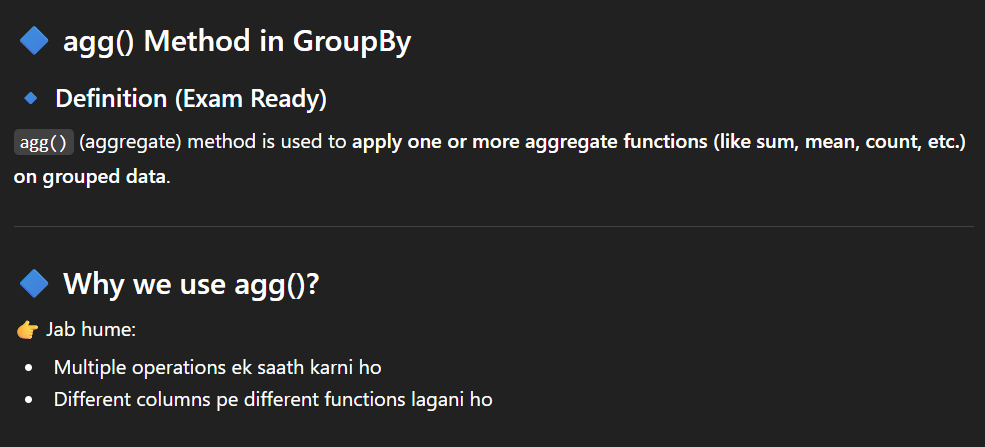

In [133]:
# agg method
# passing dict

genres.agg(
    {
        'Runtime':'mean',
        'IMDB_Rating':'mean',
        'No_of_Votes':'sum',
        'Gross':'sum',
        'Metascore':'min'
    }
)

,Runtime,IMDB_Rating,No_of_Votes,Gross,Metascore
Genre,,,,,
Action,129.046512,7.949419,72282412,3.263226e+10,33.0
Adventure,134.111111,7.937500,22576163,9.496922e+09,41.0
Animation,99.585366,7.930488,21978630,1.463147e+10,61.0
Biography,136.022727,7.938636,24006844,8.276358e+09,48.0
Comedy,112.129032,7.901290,27620327,1.566387e+10,45.0
Crime,126.392523,8.016822,33533615,8.452632e+09,47.0
Drama,124.737024,7.957439,61367304,3.540997e+10,28.0
Family,107.500000,7.800000,551221,4.391106e+08,67.0
Fantasy,85.000000,8.000000,146222,7.827267e+08,NaN


In [137]:
# passing list
genres.agg(['min','max'])

Series_Title  \
                                       min   
Genre                                        
Action                                 300   
Adventure            2001: A Space Odyssey   
Animation                            Akira   
Biography                 12 Years a Slave   
Comedy                (500) Days of Summer   
Crime                         12 Angry Men   
Drama                                 1917   
Family          E.T. the Extra-Terrestrial   
Fantasy       Das Cabinet des Dr. Caligari   
Film-Noir                Shadow of a Doubt   
Horror                               Alien   
Mystery                          Dark City   
Thriller                   Wait Until Dark   
Western    Il buono, il brutto, il cattivo   

                                               Released_Year       Runtime  \
                                           max           min   max     min   
Genre                                                                        
Action                                 Yôjinbô          1924  2019      45   
Adventure                           Zombieland          1925    PG      88   
Animation          Ôkami kodomo no Ame to Yuki          1940  2020      71   
Biography                              Zerkalo          1928  2020      93   
Comedy                Zindagi Na Milegi Dobara          1921  2020      68   
Crime                        À bout de souffle          1931  2019      80   
Drama                                Zwartboek          1925  2020      64   
Family     Willy Wonka & the Chocolate Factory          1971  1982     100   
Fantasy                              Nosferatu          1920  1922      76   
Film-Noir                        The Third Man          1941  1949     100   
Horror                               The Thing          1933  2017      71   
Mystery                                Vertigo          1938  2012      96   
Thriller                       Wait Until Dark          1967  1967     108   
Western                 The Outlaw Josey Wales          1965  1976     132   

               IMDB_Rating                    Director                    \
           max         min  max                    min               max   
Genre                                                                      
Action     321         7.6  9.0       Abhishek Chaubey       Zack Snyder   
Adventure  228         7.6  8.6         Akira Kurosawa  Ömer Faruk Sorak   
Animation  137         7.6  8.6            Adam Elliot   Yoshifumi Kondô   
Biography  209         7.6  8.9             Adam McKay      Tom McCarthy   
Comedy     188         7.6  8.6  Alejandro G. Iñárritu       Zoya Akhtar   
Crime      229         7.6  9.2         Akira Kurosawa      Yavuz Turgul   
Drama      242         7.6  9.3             Aamir Khan       Çagan Irmak   
Family     115         7.8  7.8             Mel Stuart  Steven Spielberg   
Fantasy     94         7.9  8.1            F.W. Murnau      Robert Wiene   
Film-Noir  108         7.8  8.1       Alfred Hitchcock       John Huston   
Horror     122         7.6  8.5     Alejandro Amenábar  William Friedkin   
Mystery    138         7.6  8.4            Alex Proyas     Terry Gilliam   
Thriller   108         7.8  7.8          Terence Young     Terence Young   
Western    165         7.8  8.8         Clint Eastwood      Sergio Leone   

                              Star1                   No_of_Votes           \
                                min               max         min      max   
Genre                                                                        
Action                   Aamir Khan      Yun-Fat Chow       25312  2303232   
Adventure                Aamir Khan      Yves Montand       29999  1512360   
Animation             Adrian Molina      Yôji Matsuda       25229   999790   
Biography              Adrien Brody     Éric Toledano       27254  1213505   
Comedy                   Aamir Khan  Ömer Faruk Sorak       26337   939631   
Cri

In [8]:
# Adding both the syntax
genres.agg(
    {
        'Runtime':['min','mean'],
        'IMDB_Rating':'mean',
        'No_of_Votes':['sum','max'],
        'Gross':'sum',
        'Metascore':'min'
    }
)

Runtime             IMDB_Rating No_of_Votes                  Gross  \
              min        mean        mean         sum      max           sum   
Genre                                                                          
Action         45  129.046512    7.949419    72282412  2303232  3.263226e+10   
Adventure      88  134.111111    7.937500    22576163  1512360  9.496922e+09   
Animation      71   99.585366    7.930488    21978630   999790  1.463147e+10   
Biography      93  136.022727    7.938636    24006844  1213505  8.276358e+09   
Comedy         68  112.129032    7.901290    27620327   939631  1.566387e+10   
Crime          80  126.392523    8.016822    33533615  1826188  8.452632e+09   
Drama          64  124.737024    7.957439    61367304  2343110  3.540997e+10   
Family        100  107.500000    7.800000      551221   372490  4.391106e+08   
Fantasy        76   85.000000    8.000000      146222    88794  7.827267e+08   
Film-Noir     100  104.000000    7.966667      367215   158731  1.259105e+08   
Horror         71  102.090909    7.909091     3742556   787806  1.034649e+09   
Mystery        96  119.083333    7.975000     4203004  1129894  1.256417e+09   
Thriller      108  108.000000    7.800000       27733    27733  1.755074e+07   
Western       132  148.250000    8.350000     1289665   688390  5.822151e+07   

          Metascore  
                min  
Genre                
Action         33.0  
Adventure      41.0  
Animation      61.0  
Biography      48.0  
Comedy         45.0  
Crime          47.0  
Drama          28.0  
Family         67.0  
Fantasy         NaN  
Film-Noir      94.0  
Horror         46.0  
Mystery        52.0  
Thriller       81.0  
Western        69.0

In [162]:
# looping on groups
for group,data in genres:
    print(data[data['IMDB_Rating'] == data['IMDB_Rating'].max()])

      Series_Title Released_Year  Runtime   Genre  IMDB_Rating  \
2  The Dark Knight          2008      152  Action          9.0   

            Director           Star1  No_of_Votes        Gross  Metascore  
2  Christopher Nolan  Christian Bale      2303232  534858444.0       84.0  
    Series_Title Released_Year  Runtime      Genre  IMDB_Rating  \
21  Interstellar          2014      169  Adventure          8.6   

             Director                Star1  No_of_Votes        Gross  \
21  Christopher Nolan  Matthew McConaughey      1512360  188020017.0   

    Metascore  
21       74.0  
                     Series_Title Released_Year  Runtime      Genre  \
23  Sen to Chihiro no kamikakushi          2001      125  Animation   

    IMDB_Rating        Director          Star1  No_of_Votes       Gross  \
23          8.6  Hayao Miyazaki  Daveigh Chase       651376  10055859.0   

    Metascore  
23       96.0  
       Series_Title Released_Year  Runtime      Genre  IMDB_Rating  \
7  Schi

In [168]:
# upper wale ko ache se dikhane ke liye new data frame me add kr do

df = pd.DataFrame(columns=movies.columns)

for group, data in genres:
    row = data[data['IMDB_Rating'] == data['IMDB_Rating'].max()]
    df = pd.concat([df, row])

df

C:\Users\moham\AppData\Local\Temp\ipykernel_6500\1000871681.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, row])


,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
2,The Dark Knight,2008,152,Action,9.0,Christopher Nolan,Christian Bale,2303232,534858444.0,84.0
21,Interstellar,2014,169,Adventure,8.6,Christopher Nolan,Matthew McConaughey,1512360,188020017.0,74.0
23,Sen to Chihiro no kamikakushi,2001,125,Animation,8.6,Hayao Miyazaki,Daveigh Chase,651376,10055859.0,96.0
7,Schindler's List,1993,195,Biography,8.9,Steven Spielberg,Liam Neeson,1213505,96898818.0,94.0
19,Gisaengchung,2019,132,Comedy,8.6,Bong Joon Ho,Kang-ho Song,552778,53367844.0,96.0
26,La vita è bella,1997,116,Comedy,8.6,Roberto Benigni,Roberto Benigni,623629,57598247.0,59.0
1,The Godfather,1972,175,Crime,9.2,Francis Ford Coppola,Marlon Brando,1620367,134966411.0,100.0
0,The Shawshank Redemption,1994,142,Drama,9.3,Frank Darabont,Tim Robbins,2343110,28341469.0,80.0
688,E.T. the Extra-Terrestrial,1982,115,Family,7.8,Steven Spielberg,Henry Thomas,372490,435110554.0,91.0
698,Willy Wonka & the Chocolate Factory,1971,100,Family,7.8,Mel Stuart,Gene Wilder,178731,4000000.0,67.0


In [9]:
# split (apply) combine
# apply -> builtin function

genres.apply(min)

C:\Users\moham\AppData\Local\Temp\ipykernel_1576\3127779659.py:4: FutureWarning: The provided callable <built-in function min> is currently using np.minimum.reduce. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string np.minimum.reduce instead.
  genres.apply(min)
C:\Users\moham\AppData\Local\Temp\ipykernel_1576\3127779659.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  genres.apply(min)


,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
Genre,,,,,,,,,,
Action,300,1924,45,Action,7.6,Abhishek Chaubey,Aamir Khan,25312,3296.0,NaN
Adventure,2001: A Space Odyssey,1925,88,Adventure,7.6,Akira Kurosawa,Aamir Khan,29999,61001.0,NaN
Animation,Akira,1940,71,Animation,7.6,Adam Elliot,Adrian Molina,25229,128985.0,NaN
Biography,12 Years a Slave,1928,93,Biography,7.6,Adam McKay,Adrien Brody,27254,21877.0,NaN
Comedy,(500) Days of Summer,1921,68,Comedy,7.6,Alejandro G. Iñárritu,Aamir Khan,26337,1305.0,NaN
Crime,12 Angry Men,1931,80,Crime,7.6,Akira Kurosawa,Ajay Devgn,27712,6013.0,NaN
Drama,1917,1925,64,Drama,7.6,Aamir Khan,Abhay Deol,25088,3600.0,NaN
Family,E.T. the Extra-Terrestrial,1971,100,Family,7.8,Mel Stuart,Gene Wilder,178731,4000000.0,67.0
Fantasy,Das Cabinet des Dr. Caligari,1920,76,Fantasy,7.9,F.W. Murnau,Max Schreck,57428,337574718.0,NaN


In [18]:
# find number of movies starting with A for each group

def foo(group):
    return group[group['Series_Title'].str.startswith("A")].shape[0]

genres.apply(foo)

C:\Users\moham\AppData\Local\Temp\ipykernel_1576\1128972633.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  genres.apply(foo)


Genre
Action       10
Adventure     2
Animation     2
Biography     9
Comedy       14
Crime         4
Drama        21
Family        0
Fantasy       0
Film-Noir     0
Horror        1
Mystery       0
Thriller      0
Western       0
dtype: int64

In [ ]:
# find ranking of each movie in the group according to IMDB score

def rank_movie(group):
  group['genre_rank'] = group['IMDB_Rating'].rank(ascending=False)
  return group

genres.apply(rank_movie)

C:\Users\moham\AppData\Local\Temp\ipykernel_1576\3697324871.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  genres.apply(rank_movie)


Series_Title Released_Year  \
Genre                                                                           
Action   2                                      The Dark Knight          2008   
         5        The Lord of the Rings: The Return of the King          2003   
         8                                            Inception          2010   
         10   The Lord of the Rings: The Fellowship of the Ring          2001   
         13               The Lord of the Rings: The Two Towers          2002   
...                                                         ...           ...   
Thriller 700                                    Wait Until Dark          1967   
Western  12                     Il buono, il brutto, il cattivo          1966   
         48                        Once Upon a Time in the West          1968   
         115                         Per qualche dollaro in più          1965   
         691                             The Outlaw Josey Wales          1976   

              Runtime     Genre  IMDB_Rating           Director  \
Genre                                                             
Action   2        152    Action          9.0  Christopher Nolan   
         5        201    Action          8.9      Peter Jackson   
         8        148    Action          8.8  Christopher Nolan   
         10       178    Action          8.8      Peter Jackson   
         13       179    Action          8.7      Peter Jackson   
...               ...       ...          ...                ...   
Thriller 700      108  Thriller          7.8      Terence Young   
Western  12       161   Western          8.8       Sergio Leone   
         48       165   Western          8.5       Sergio Leone   
         115      132   Western          8.3       Sergio Leone   
         691      135   Western          7.8     Clint Eastwood   

                          Star1  No_of_Votes        Gross  Metascore  \
Genre                                                                  
Action   2       Christian Bale      2303232  534858444.0       84.0   
         5          Elijah Wood      1642758  377845905.0       94.0   
         8    Leonardo DiCaprio      2067042  292576195.0       74.0   
         10         Elijah Wood      1661481  315544750.0       92.0   
         13         Elijah Wood      1485555  342551365.0       87.0   
...                         ...          ...          ...        ...   
Thriller 700     Audrey Hepburn        27733   17550741.0       81.0   
Western  12      Clint Eastwood       688390    6100000.0       90.0   
         48         Henry Fonda       302844    5321508.0       80.0   
         115     Clint Eastwood       232772   15000000.0       74.0   
         691     Clint Eastwood        65659   31800000.0       69.0   

              genre_rank  
Genre                     
Action   2           1.0  
         5           2.0  
         8           3.5  
         10          3.5  
         13          6.0  
...                  ...  
Thriller 700         1.0  
Western  12          1.0  
         48          2.0  
         115         3.0  
         691         4.0  

[1000 rows x 11 columns]

In [41]:
# find normalized IMDB rating group wise

def normal(group):
    group['normalized_rating'] = (group['IMDB_Rating']-group['IMDB_Rating'].min()) / (group['IMDB_Rating'].max()-group['IMDB_Rating'].min())
    return group

genres.apply(normal)

C:\Users\moham\AppData\Local\Temp\ipykernel_1576\883012087.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  genres.apply(normal)


Series_Title Released_Year  \
Genre                                                                           
Action   2                                      The Dark Knight          2008   
         5        The Lord of the Rings: The Return of the King          2003   
         8                                            Inception          2010   
         10   The Lord of the Rings: The Fellowship of the Ring          2001   
         13               The Lord of the Rings: The Two Towers          2002   
...                                                         ...           ...   
Thriller 700                                    Wait Until Dark          1967   
Western  12                     Il buono, il brutto, il cattivo          1966   
         48                        Once Upon a Time in the West          1968   
         115                         Per qualche dollaro in più          1965   
         691                             The Outlaw Josey Wales          1976   

              Runtime     Genre  IMDB_Rating           Director  \
Genre                                                             
Action   2        152    Action          9.0  Christopher Nolan   
         5        201    Action          8.9      Peter Jackson   
         8        148    Action          8.8  Christopher Nolan   
         10       178    Action          8.8      Peter Jackson   
         13       179    Action          8.7      Peter Jackson   
...               ...       ...          ...                ...   
Thriller 700      108  Thriller          7.8      Terence Young   
Western  12       161   Western          8.8       Sergio Leone   
         48       165   Western          8.5       Sergio Leone   
         115      132   Western          8.3       Sergio Leone   
         691      135   Western          7.8     Clint Eastwood   

                          Star1  No_of_Votes        Gross  Metascore  \
Genre                                                                  
Action   2       Christian Bale      2303232  534858444.0       84.0   
         5          Elijah Wood      1642758  377845905.0       94.0   
         8    Leonardo DiCaprio      2067042  292576195.0       74.0   
         10         Elijah Wood      1661481  315544750.0       92.0   
         13         Elijah Wood      1485555  342551365.0       87.0   
...                         ...          ...          ...        ...   
Thriller 700     Audrey Hepburn        27733   17550741.0       81.0   
Western  12      Clint Eastwood       688390    6100000.0       90.0   
         48         Henry Fonda       302844    5321508.0       80.0   
         115     Clint Eastwood       232772   15000000.0       74.0   
         691     Clint Eastwood        65659   31800000.0       69.0   

              normalized_rating  
Genre                            
Action   2             1.000000  
         5             0.928571  
         8             0.857143  
         10            0.857143  
         13            0.785714  
...                         ...  
Thriller 700                NaN  
Western  12            1.000000  
         48            0.700000  
         115           0.500000  
         691           0.000000  

[1000 rows x 11 columns]

In [3]:
# groupby on multiple cols
duo = movies.groupby(['Director','Star1'])
duo
# size
duo.size()
# get_group
duo.get_group(('Aamir Khan','Amole Gupte'))

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
65,Taare Zameen Par,2007,165,Drama,8.4,Aamir Khan,Amole Gupte,168895,1223869.0,NaN


In [50]:
# find the most earning actor->director combo
duo['Gross'].sum().sort_values(ascending=False).head(1)

Director        Star1         
Akira Kurosawa  Toshirô Mifune    2.999877e+09
Name: Gross, dtype: float64

In [68]:
# find the best(in-terms of metascore(avg)) actor->genre combo

duo = movies.groupby(['Star1','Genre'])
duo['Metascore'].mean().reset_index().sort_values('Metascore',ascending=False).head(1)

,Star1,Genre,Metascore
77,Bertil Guve,Drama,100.0


In [66]:
# agg on multiple groupby
duo.agg(['min','max'])

Series_Title  \
                                                              min   
Star1                Genre                                          
Aamir Khan           Action                       Andaz Apna Apna   
                     Adventure  Lagaan: Once Upon a Time in India   
                     Comedy                              3 Idiots   
Aaron Taylor-Johnson Action                              Kick-Ass   
Abhay Deol           Drama                                  Dev.D   
...                                                           ...   
Zbigniew Zamachowski Comedy                 Trois couleurs: Blanc   
Zooey Deschanel      Comedy                  (500) Days of Summer   
Çetin Tekindor       Drama                         Babam ve Oglum   
Éric Toledano        Biography                   The Intouchables   
Ömer Faruk Sorak     Comedy                             Vizontele   

                                                                   \
                                                              max   
Star1                Genre                                          
Aamir Khan           Action                                Dangal   
                     Adventure  Lagaan: Once Upon a Time in India   
                     Comedy                       Rang De Basanti   
Aaron Taylor-Johnson Action                              Kick-Ass   
Abhay Deol           Drama                                  Dev.D   
...                                                           ...   
Zbigniew Zamachowski Comedy                 Trois couleurs: Blanc   
Zooey Deschanel      Comedy                  (500) Days of Summer   
Çetin Tekindor       Drama                         Babam ve Oglum   
Éric Toledano        Biography                   The Intouchables   
Ömer Faruk Sorak     Comedy                             Vizontele   

                               Released_Year       Runtime      IMDB_Rating  \
                                         min   max     min  max         min   
Star1                Genre                                                    
Aamir Khan           Action             1994  2016     160  161         8.2   
                     Adventure          2001  2001     224  224         8.1   
                     Comedy             2001  2014     153  183         8.1   
Aaron Taylor-Johnson Action             2010  2010     117  117         7.6   
Abhay Deol           Drama              2009  2009     144  144         8.0   
...                                      ...   ...     ...  ...         ...   
Zbigniew Zamachowski Comedy             1994  1994      92   92         7.6   
Zooey Deschanel      Comedy             2009  2009      95   95         7.7   
Çetin Tekindor       Drama              2005  2005     112  112         8.3   
Éric Toledano        Biography          2011  2011     112  112         8.5   
Ömer Faruk Sorak     Comedy             2001  2001     110  110         8.0   

                                                 Director  \
                                max                   min   
Star1                Genre                                  
Aamir Khan           Action     8.4         Nitesh Tiwari   
                     Adventure  8.1    Ashutosh Gowariker   
                     Comedy     8.4         Farhan Akhtar   
Aaron Taylor-Johnson Action     7.6        Matthew Vaughn   
Abhay Deol           Drama      8.0        Anurag Kashyap   
...                             ...                   ...   
Zbigniew Zamachowski Comedy     7.6  Krzysztof Kieslowski   
Zooey Deschanel      Comedy     7.7             Marc Webb   
Çetin Tekindor       Drama      8.3           Çagan Irmak   
Éric Toledano        Biography  8.5       Olivier Nakache   
Ömer Faruk Sorak     Comedy     8.0        Yilmaz Erdogan   

                                                        No_of_Votes          \
                                                    max         min     max   

### Excercise

In [4]:
ipl = pd.read_csv('deliveries.csv')
ipl.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [5]:
ipl.shape

(179078, 21)

In [13]:
# find the top 10 batsman in terms of runs
ipl.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)

batsman
V Kohli           5434
SK Raina          5415
RG Sharma         4914
DA Warner         4741
S Dhawan          4632
CH Gayle          4560
MS Dhoni          4477
RV Uthappa        4446
AB de Villiers    4428
G Gambhir         4223
Name: batsman_runs, dtype: int64

In [93]:
ipl.groupby('batsman')['batsman_runs']

In [39]:
# find the batsman with max no of sixesipl[]
df = ipl[ipl['batsman_runs']==6]
df.groupby('batsman')['batsman_runs'].count().sort_values(ascending=False).head(1).index[0]

'CH Gayle'

In [55]:
# find batsman with most number of 4's and 6's in last 5 overs
df = ipl[ipl['over']>15]
new_df = df[(df['batsman_runs'] == 6) | (df['batsman_runs'] == 4)]
new_df.groupby('batsman')['batsman_runs'].count().sort_values(ascending=False).head(1).index[0]

'MS Dhoni'

In [71]:
# find V Kohli's record against all teams
df = ipl[ipl['batsman'] == 'V Kohli']
df.groupby('bowling_team')['batsman_runs'].sum().sort_values(ascending=False).reset_index()

,bowling_team,batsman_runs
0,Delhi Daredevils,763
1,Chennai Super Kings,749
2,Kolkata Knight Riders,675
3,Kings XI Punjab,636
4,Mumbai Indians,628
5,Sunrisers Hyderabad,509
6,Rajasthan Royals,370
7,Deccan Chargers,306
8,Gujarat Lions,283
9,Rising Pune Supergiants,188


In [93]:
# find the highest score of v kohli
team_df = ipl[ipl['batsman'] == 'V Kohli']
team_df.groupby('match_id')['batsman_runs'].sum().sort_values(ascending=False).head(1).values[0]

np.int64(113)

In [94]:
# Create a function that can return the highest score of any batsman

def highest_score(batsman_name):
    team_df = ipl[ipl['batsman'] == batsman_name]
    return team_df.groupby('match_id')['batsman_runs'].sum().sort_values(ascending=False).head(1).values[0]


print(highest_score('V Kohli'))


113
